In [90]:
import pandas as pd
from transformers import pipeline
from pathlib import Path
from dotenv import load_dotenv
import requests
import io
import gdown
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
load_dotenv()

True

In [101]:
df = pd.read_csv("../data/raw/minutes_text.csv")

finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    top_k=None
)

def score_full_document(text):
    chunks = [text[i:i+400] for i in range(0, len(text), 400)]
    pos, neg, neu = [], [], []

    for chunk in chunks:
        if len(chunk.strip()) < 50:
            continue
        result = finbert(chunk)[0]
        scores = {item["label"]: item["score"] for item in result}
        pos.append(scores.get("positive", 0))
        neg.append(scores.get("negative", 0))
        neu.append(scores.get("neutral", 0))

    return {
        "positive": sum(pos) / len(pos),
        "negative": sum(neg) / len(neg),
        "neutral": sum(neu) / len(neu),
    }

results = []
for i, row in df.iterrows():
    scores = score_full_document(row["text"])
    results.append({
        "year": row["year"],
        "month": row["month"],
        "date_str": row["date_str"],
        "positive": scores["positive"],
        "negative": scores["negative"],
        "neutral": scores["neutral"],
    })
    print(f"✓ {row['date_str']}")

scores_df = pd.DataFrame(results)
scores_df["dominant"] = scores_df[["positive", "negative", "neutral"]].idxmax(axis=1)
scores_df.to_csv("../data/processed/sentiment_scores_full.csv", index=False)

✓ august 2015
✓ december 2015
✓ february 2015
✓ january 2015
✓ june 2015
✓ march 2015
✓ may 2015
✓ november 2015
✓ september 2015
✓ august 2016
✓ december 2016
✓ february 2016
✓ june 2016
✓ march 2016
✓ may 2016
✓ november 2016
✓ september 2016
✓ august 2017
✓ december 2017
✓ february 2017
✓ june 2017
✓ march 2017
✓ may 2017
✓ november 2017
✓ september 2017
✓ august 2018
✓ december 2018
✓ february 2018
✓ june 2018
✓ march 2018
✓ may 2018
✓ november 2018
✓ september 2018
✓ august 2019
✓ december 2019
✓ june 2019
✓ march 2019
✓ may 2019
✓ november 2019
✓ september 2019
✓ august 2020
✓ december 2020
✓ january 2020
✓ june 2020
✓ march 2020
✓ may 2020
✓ november 2020
✓ september 2020
✓ august 2021
✓ december 2021
✓ february 2021
✓ june 2021
✓ march 2021
✓ may 2021
✓ november 2021
✓ september 2021
✓ august 2022
✓ december 2022
✓ february 2022
✓ june 2022
✓ march 2022
✓ may 2022
✓ november 2022
✓ september 2022
✓ august 2023
✓ december 2023
✓ february 2023
✓ june 2023
✓ march 2023
✓ may 2023


,year,month,date_str,positive,negative,neutral,dominant
0,2015,august,august 2015,0.329136,0.442867,0.227997,negative
1,2015,december,december 2015,0.286332,0.476057,0.237611,negative
2,2015,february,february 2015,0.253068,0.608396,0.138537,negative
3,2015,january,january 2015,0.193236,0.638300,0.168464,negative
4,2015,june,june 2015,0.251975,0.551140,0.196885,negative
5,2015,march,march 2015,0.364656,0.416673,0.218671,negative
6,2015,may,may 2015,0.244188,0.617815,0.137998,negative
7,2015,november,november 2015,0.273678,0.565614,0.160708,negative
8,2015,september,september 2015,0.313895,0.515990,0.170115,negative
9,2016,august,august 2016,0.279439,0.505510,0.215052,negative


In [109]:
bank_rate = pd.read_csv("../data/raw/bank_rate.csv")

# Rename columns
bank_rate.columns = ["date", "bank_rate"]

# Clean and parse date
bank_rate["date"] = pd.to_datetime(bank_rate["date"], format="%d %b %y")

# Sort chronologically
bank_rate = bank_rate.sort_values("date").reset_index(drop=True)

# Convert bank_rate to numeric
bank_rate["bank_rate"] = pd.to_numeric(bank_rate["bank_rate"], errors="coerce")

        date  bank_rate
0 2015-01-31        0.5
1 2015-02-28        0.5
2 2015-03-31        0.5
3 2015-04-30        0.5
4 2015-05-31        0.5
date         datetime64[us]
bank_rate           float64
dtype: object


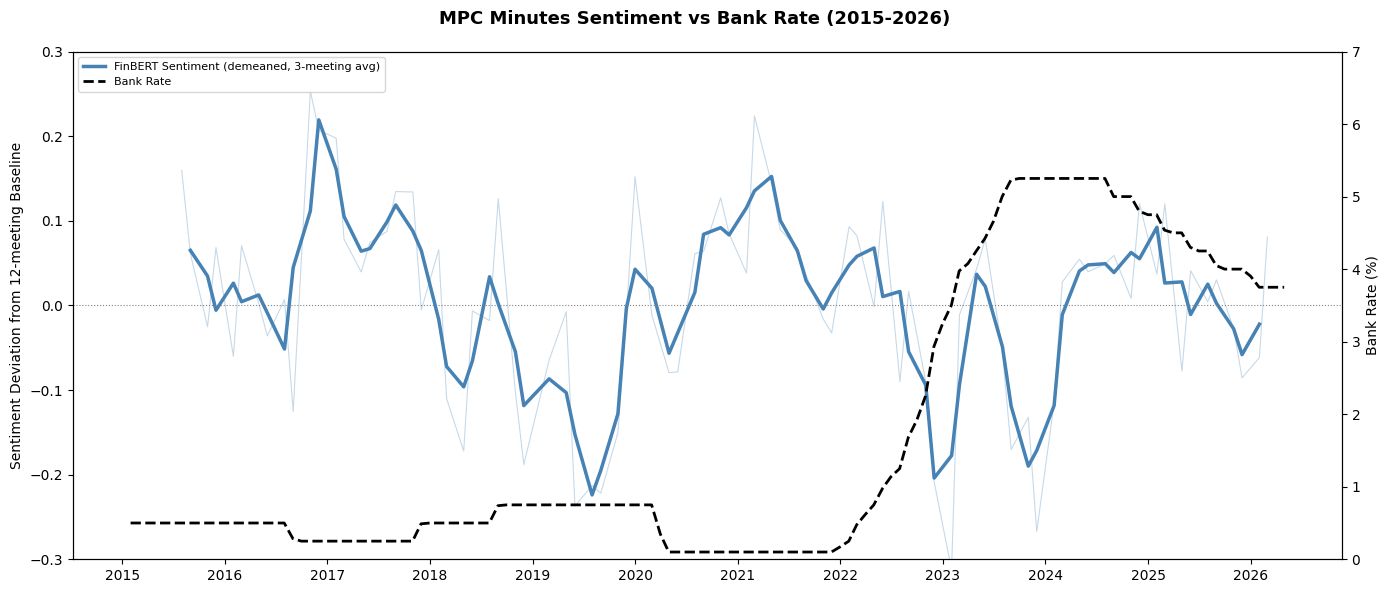

In [119]:
scores_df["finbert_net"] = scores_df["positive"] - scores_df["negative"]
scores_df["finbert_smoothed"] = scores_df["finbert_net"].rolling(window=3, center=True).mean()
rolling_mean = scores_df["finbert_net"].rolling(window=12, min_periods=6).mean()
scores_df["finbert_demeaned"] = scores_df["finbert_net"] - rolling_mean
scores_df["finbert_demeaned_smooth"] = scores_df["finbert_demeaned"].rolling(window=3, center=True).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(scores_df["date"], scores_df["finbert_demeaned"], color="steelblue", alpha=0.3, linewidth=0.8)
ax1.plot(scores_df["date"], scores_df["finbert_demeaned_smooth"], color="steelblue", linewidth=2.5, label="FinBERT Sentiment (demeaned, 3-meeting avg)")
ax1.axhline(0, color="grey", linewidth=0.8, linestyle=":")
ax1.set_ylabel("Sentiment Deviation from 12-meeting Baseline")
ax1.set_ylim(-0.3, 0.3)

ax2 = ax1.twinx()
ax2.plot(bank_rate["date"], bank_rate["bank_rate"], label="Bank Rate", color="black", linewidth=2, linestyle="--")
ax2.set_ylabel("Bank Rate (%)")
ax2.set_ylim(0, 7)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45)
fig.suptitle("MPC Minutes Sentiment vs Bank Rate (2015-2026)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()